# Giới thiệu

Bài demo này minh họa **sức mạnh của instruction** trong việc điều khiển embedding, giúp phân biệt ngữ nghĩa của cùng một text trong các ngữ cảnh khác nhau.

## Ý nghĩa chính của INSTRUCTOR:
1. **Disambiguation**: Cùng một từ/câu có thể có embedding khác nhau tùy theo instruction
2. **Task-aware**: Instruction giúp model hiểu và tạo embedding phù hợp với từng task cụ thể
3. **Flexibility**: Một model có thể phục vụ nhiều task khác nhau chỉ bằng cách thay đổi instruction

In [1]:
import sys
import os
import numpy as np
import torch
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, './instructor-embedding')
from InstructorEmbedding import INSTRUCTOR

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("CUDA device:", torch.cuda.get_device_name(0))

c:\Users\Admin\miniconda3\envs\instructor\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch version: 2.9.1+cpu
CUDA available: False


## Load Model Instructor-Large

Sử dụng model `hkunlp/instructor-large` đã được pretrained.

In [2]:
model = INSTRUCTOR('hkunlp/instructor-large')
print("Model loaded successfully!")

c:\Users\Admin\miniconda3\envs\instructor\lib\site-packages\transformers\utils\generic.py:260: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  torch.utils._pytree._register_pytree_node(


Model loaded successfully!


## Demo 1: Disambiguation - Phân biệt ngữ nghĩa với Instruction

**Đây là ý nghĩa cốt lõi của INSTRUCTOR**: Cùng một từ "Apple" nhưng với instruction khác nhau sẽ cho embedding khác nhau, giúp model hiểu đúng ngữ cảnh (công ty tech vs trái cây).

Chúng ta sẽ so sánh:
- "Apple" với instruction về công nghệ → gần với Microsoft, iPhone
- "Apple" với instruction về trái cây → gần với Orange, Banana

In [3]:
sentences_tech_context = [
    ["Represent the technology company for retrieval:", "Apple"],
    ["Represent the technology company for retrieval:", "Microsoft develops Windows operating system"],
    ["Represent the technology company for retrieval:", "iPhone is a popular smartphone made by Apple"],
    ["Represent the technology company for retrieval:", "Google creates Android operating system"],
]

sentences_fruit_context = [
    ["Represent the fruit for retrieval:", "Apple"],
    ["Represent the fruit for retrieval:", "Orange is rich in vitamin C"],
    ["Represent the fruit for retrieval:", "Banana is a tropical fruit"],
    ["Represent the fruit for retrieval:", "Grapes are used to make wine"],
]

embeddings_tech = model.encode(sentences_tech_context)
embeddings_fruit = model.encode(sentences_fruit_context)

print("\nTech context sentences:")
for i, s in enumerate(sentences_tech_context):
    print(f"  {i}: {s[1]}")
print("\nFruit context sentences:")
for i, s in enumerate(sentences_fruit_context):
    print(f"  {i}: {s[1]}")


Tech context sentences:
  0: Apple
  1: Microsoft develops Windows operating system
  2: iPhone is a popular smartphone made by Apple
  3: Google creates Android operating system

Fruit context sentences:
  0: Apple
  1: Orange is rich in vitamin C
  2: Banana is a tropical fruit
  3: Grapes are used to make wine


In [4]:
apple_as_tech = embeddings_tech[0]  # "Apple" với instruction tech
apple_as_fruit = embeddings_fruit[0]  # "Apple" với instruction fruit

microsoft = embeddings_tech[1]
iphone = embeddings_tech[2]
google = embeddings_tech[3]

orange = embeddings_fruit[1]
banana = embeddings_fruit[2]
grapes = embeddings_fruit[3]

print("=" * 60)
print("KHI 'APPLE' ĐƯỢC HIỂU LÀ CÔNG TY CÔNG NGHỆ:")
print("=" * 60)
print(f"  Similarity với Microsoft: {cosine_similarity([apple_as_tech], [microsoft])[0][0]:.4f}")
print(f"  Similarity với iPhone:    {cosine_similarity([apple_as_tech], [iphone])[0][0]:.4f}")
print(f"  Similarity với Google:    {cosine_similarity([apple_as_tech], [google])[0][0]:.4f}")
print(f"  Similarity với Orange:    {cosine_similarity([apple_as_tech], [orange])[0][0]:.4f}")
print(f"  Similarity với Banana:    {cosine_similarity([apple_as_tech], [banana])[0][0]:.4f}")

print("\n" + "=" * 60)
print("KHI 'APPLE' ĐƯỢC HIỂU LÀ TRÁI CÂY:")
print("=" * 60)
print(f"  Similarity với Orange:    {cosine_similarity([apple_as_fruit], [orange])[0][0]:.4f}")
print(f"  Similarity với Banana:    {cosine_similarity([apple_as_fruit], [banana])[0][0]:.4f}")
print(f"  Similarity với Grapes:    {cosine_similarity([apple_as_fruit], [grapes])[0][0]:.4f}")
print(f"  Similarity với Microsoft: {cosine_similarity([apple_as_fruit], [microsoft])[0][0]:.4f}")
print(f"  Similarity với iPhone:    {cosine_similarity([apple_as_fruit], [iphone])[0][0]:.4f}")

print("\n" + "=" * 60)
print("SỰ KHÁC BIỆT GIỮA 2 'APPLE':")
print("=" * 60)
print(f"  Similarity('Apple tech', 'Apple fruit'): {cosine_similarity([apple_as_tech], [apple_as_fruit])[0][0]:.4f}")
print("  → Cùng từ 'Apple' nhưng embedding KHÁC NHAU nhờ instruction!")

KHI 'APPLE' ĐƯỢC HIỂU LÀ CÔNG TY CÔNG NGHỆ:
  Similarity với Microsoft: 0.7560
  Similarity với iPhone:    0.9121
  Similarity với Google:    0.7673
  Similarity với Orange:    0.7432
  Similarity với Banana:    0.7550

KHI 'APPLE' ĐƯỢC HIỂU LÀ TRÁI CÂY:
  Similarity với Orange:    0.8196
  Similarity với Banana:    0.8303
  Similarity với Grapes:    0.7982
  Similarity với Microsoft: 0.7733
  Similarity với iPhone:    0.8844

SỰ KHÁC BIỆT GIỮA 2 'APPLE':
  Similarity('Apple tech', 'Apple fruit'): 0.9622
  → Cùng từ 'Apple' nhưng embedding KHÁC NHAU nhờ instruction!


### Visualization

Trực quan hóa sự khác biệt embedding khi cùng một text được encode với instruction khác nhau.

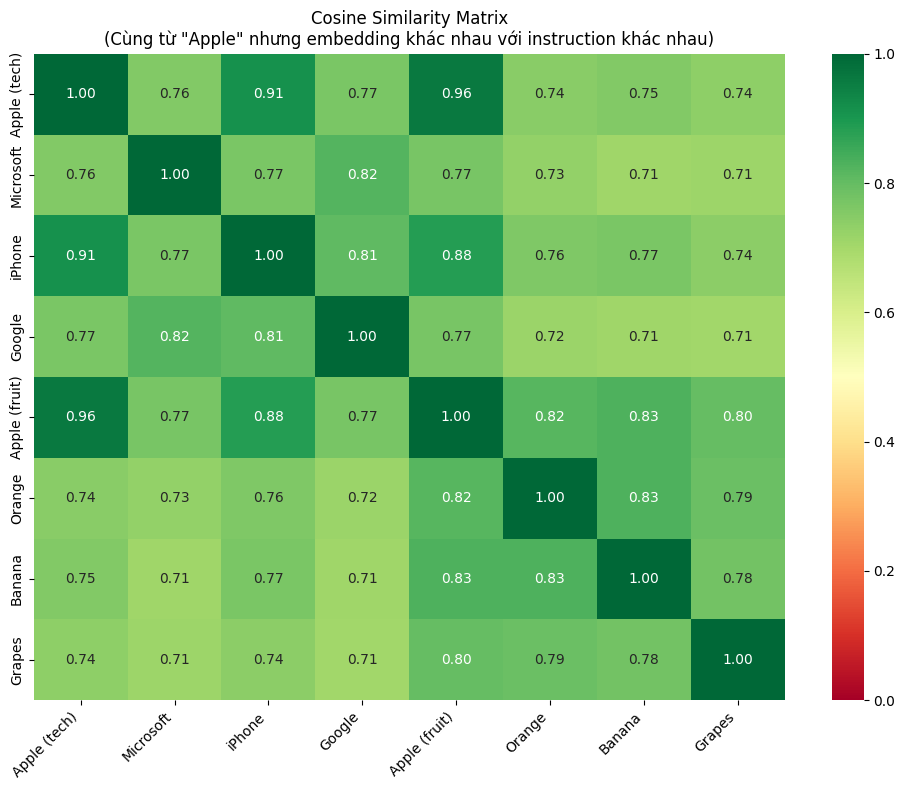


Quan sát, ta thấy:
   - 'Apple (tech)' có similarity CAO với Microsoft, iPhone, Google
   - 'Apple (fruit)' có similarity CAO với Orange, Banana, Grapes
   - 'Apple (tech)' và 'Apple (fruit)' có similarity THẤP với nhau


In [5]:
all_embeddings = np.vstack([embeddings_tech, embeddings_fruit])
labels = [
    "Apple (tech)", "Microsoft", "iPhone", "Google",
    "Apple (fruit)", "Orange", "Banana", "Grapes"
]

sim_matrix = cosine_similarity(all_embeddings)

plt.figure(figsize=(10, 8))
sns.heatmap(sim_matrix, annot=True, fmt='.2f', xticklabels=labels, yticklabels=labels, cmap='RdYlGn', vmin=0, vmax=1)
plt.title('Cosine Similarity Matrix\n(Cùng từ "Apple" nhưng embedding khác nhau với instruction khác nhau)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nQuan sát, ta thấy:")
print("   - 'Apple (tech)' có similarity CAO với Microsoft, iPhone, Google")
print("   - 'Apple (fruit)' có similarity CAO với Orange, Banana, Grapes")
print("   - 'Apple (tech)' và 'Apple (fruit)' có similarity THẤP với nhau")

## Demo 2: Task-Specific Instructions

Một văn bản có thể được encode khác nhau tùy theo task: **retrieval**, **classification**, **clustering**, **semantic similarity**.

In [6]:
text = "Machine learning is transforming how we analyze data"

task_instructions = {
    "retrieval_query": "Represent the question for retrieving relevant documents:",
    "retrieval_doc": "Represent the document for retrieval:",
    "classification": "Represent the sentence for classification:",
    "clustering": "Represent the sentence for clustering:",
    "similarity": "Represent the sentence for semantic similarity:",
}

embeddings_by_task = {}
for task, instruction in task_instructions.items():
    embeddings_by_task[task] = model.encode([[instruction, text]])[0]

print(f"Text: \"{text}\"\n")

tasks = list(task_instructions.keys())
print(f"{'Task 1':<20} {'Task 2':<20} {'Similarity':>12}")
print("-" * 55)
for i in range(len(tasks)):
    for j in range(i+1, len(tasks)):
        sim = cosine_similarity([embeddings_by_task[tasks[i]]], 
                               [embeddings_by_task[tasks[j]]])[0][0]
        print(f"{tasks[i]:<20} {tasks[j]:<20} {sim:>12.4f}")

Text: "Machine learning is transforming how we analyze data"

Task 1               Task 2                 Similarity
-------------------------------------------------------
retrieval_query      retrieval_doc              0.9936
retrieval_query      classification             0.9733
retrieval_query      clustering                 0.9739
retrieval_query      similarity                 0.9845
retrieval_doc        classification             0.9718
retrieval_doc        clustering                 0.9720
retrieval_doc        similarity                 0.9867
classification       clustering                 0.9953
classification       similarity                 0.9857
clustering           similarity                 0.9842


## Demo 3: Retrieval - Query và Document với instruction phù hợp

Trong retrieval, query và document cần instruction KHÁC NHAU để đạt hiệu quả tốt nhất.

In [7]:
documents = [
    "Python is a programming language known for its simple syntax.",
    "Machine learning algorithms can learn patterns from data.",
    "The Eiffel Tower is located in Paris, France.",
    "Neural networks are inspired by the human brain.",
    "Climate change is affecting global weather patterns.",
    "Deep learning is a subset of machine learning.",
    "The Great Wall of China is a famous landmark.",
    "Natural language processing enables computers to understand text."
]

query = "How do computers understand human language?"
query_instruction = "Represent the question for retrieving supporting documents:"
doc_instruction = "Represent the document for retrieval:"

query_emb = model.encode([[query_instruction, query]])
doc_embs = model.encode([[doc_instruction, doc] for doc in documents])

similarities = cosine_similarity(query_emb, doc_embs)[0]
ranked = sorted(enumerate(similarities), key=lambda x: x[1], reverse=True)

print(f"Query: \"{query}\"\n")
print("=" * 70)
print("KẾT QUẢ RETRIEVAL (với instruction phù hợp cho query và document):")
print("=" * 70)
for rank, (idx, score) in enumerate(ranked, 1):
    marker = "✓" if "language" in documents[idx].lower() or "text" in documents[idx].lower() else " "
    print(f"#{rank} [{marker}] (score: {score:.4f}): {documents[idx]}")

Query: "How do computers understand human language?"

KẾT QUẢ RETRIEVAL (với instruction phù hợp cho query và document):
#1 [✓] (score: 0.9042): Natural language processing enables computers to understand text.
#2 [ ] (score: 0.8414): Machine learning algorithms can learn patterns from data.
#3 [ ] (score: 0.8245): Neural networks are inspired by the human brain.
#4 [✓] (score: 0.8157): Python is a programming language known for its simple syntax.
#5 [ ] (score: 0.8008): Deep learning is a subset of machine learning.
#6 [ ] (score: 0.7430): The Great Wall of China is a famous landmark.
#7 [ ] (score: 0.7347): The Eiffel Tower is located in Paris, France.
#8 [ ] (score: 0.6971): Climate change is affecting global weather patterns.


## Demo 4: So sánh Query-Doc instruction đúng vs sai

Điều gì xảy ra nếu dùng SAI instruction? (vd: dùng cùng instruction cho cả query và document)

In [12]:
# ĐÚNG: Query dùng query_instruction, Doc dùng doc_instruction
query_emb_correct = model.encode([[query_instruction, query]])
doc_embs_correct = model.encode([[doc_instruction, doc] for doc in documents])
sim_correct = cosine_similarity(query_emb_correct, doc_embs_correct)[0]

# SAI: Dùng cùng instruction cho cả query và doc (dùng doc instruction)
query_emb_wrong = model.encode([[doc_instruction, query]])
doc_embs_wrong = model.encode([[doc_instruction, doc] for doc in documents])
sim_wrong = cosine_similarity(query_emb_wrong, doc_embs_wrong)[0]

ranked_correct = sorted(enumerate(sim_correct), key=lambda x: x[1], reverse=True)
ranked_wrong = sorted(enumerate(sim_wrong), key=lambda x: x[1], reverse=True)

print("Query:", query)
print("\n" + "=" * 80)
print(f"{'ĐÚNG (Query+Doc instructions)':^38} | {'SAI (Cùng instruction)':^35}")
print("=" * 80)

for i in range(min(5, len(documents))):
    idx_c, score_c = ranked_correct[i]
    idx_w, score_w = ranked_wrong[i]
    doc_c = documents[idx_c][:25] + "..."
    doc_w = documents[idx_w][:25] + "..."
    print(f"#{i+1} {score_c:.3f}: {doc_c:<28} | #{i+1} {score_w:.3f}: {doc_w}")

Query: How do computers understand human language?

    ĐÚNG (Query+Doc instructions)      |       SAI (Cùng instruction)       
#1 0.904: Natural language processi... | #1 0.913: Natural language processi...
#2 0.841: Machine learning algorith... | #2 0.850: Machine learning algorith...
#3 0.825: Neural networks are inspi... | #3 0.838: Neural networks are inspi...
#4 0.816: Python is a programming l... | #4 0.829: Python is a programming l...
#5 0.801: Deep learning is a subset... | #5 0.814: Deep learning is a subset...


## Demo 5: Clustering với instruction phù hợp

Khi clustering theo chủ đề, instruction giúp model focus vào đặc trưng chủ đề thay vì các đặc trưng khác.

In [9]:
texts = [
    # Sports
    "The football match ended with a dramatic goal in overtime.",
    "Basketball players need excellent jumping abilities.",
    "Tennis requires both physical and mental strength.",
    # Technology  
    "Artificial intelligence is transforming many industries.",
    "Quantum computing promises unprecedented processing power.",
    "Cybersecurity is essential in the digital age.",
    # Food
    "Italian pasta dishes are popular worldwide.",
    "Sushi is a traditional Japanese cuisine.",
    "French pastries are known for their delicate flavors."
]

true_labels = [0, 0, 0, 1, 1, 1, 2, 2, 2]  # 0=Sports, 1=Tech, 2=Food
label_names = ['Sports', 'Technology', 'Food']

cluster_instruction = "Represent the news article for topic clustering:"

embeddings_cluster = model.encode([[cluster_instruction, t] for t in texts])

print("Texts for clustering (by topic):")
for i, (text, label) in enumerate(zip(texts, true_labels)):
    print(f"  [{label_names[label]}] {text[:50]}...")

Texts for clustering (by topic):
  [Sports] The football match ended with a dramatic goal in o...
  [Sports] Basketball players need excellent jumping abilitie...
  [Sports] Tennis requires both physical and mental strength....
  [Technology] Artificial intelligence is transforming many indus...
  [Technology] Quantum computing promises unprecedented processin...
  [Technology] Cybersecurity is essential in the digital age....
  [Food] Italian pasta dishes are popular worldwide....
  [Food] Sushi is a traditional Japanese cuisine....
  [Food] French pastries are known for their delicate flavo...


In [13]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, silhouette_score

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
pred_labels = kmeans.fit_predict(embeddings_cluster)

ari = adjusted_rand_score(true_labels, pred_labels)
sil = silhouette_score(embeddings_cluster, pred_labels)

print("=== CLUSTERING EVALUATION ===\n")
print(f"Adjusted Rand Index: {ari:.4f}")
print(f"Silhouette Score:    {sil:.4f}")

print("\n=== KẾT QUẢ ===")
print(f"{'Text':<55} {'True':>12} {'Pred':>12}")
print("-" * 85)
for i, (text, true, pred) in enumerate(zip(texts, true_labels, pred_labels)):
    match = "✓" if true == pred else "✗"
    print(f"{text[:52]+'...':<55} {label_names[true]:>12} {pred:>12} {match}")

=== CLUSTERING EVALUATION ===

Adjusted Rand Index: 1.0000
Silhouette Score:    0.1329

=== KẾT QUẢ ===
Text                                                            True         Pred
-------------------------------------------------------------------------------------
The football match ended with a dramatic goal in ove...       Sports            2 ✗
Basketball players need excellent jumping abilities....       Sports            2 ✗
Tennis requires both physical and mental strength....         Sports            2 ✗
Artificial intelligence is transforming many industr...   Technology            0 ✗
Quantum computing promises unprecedented processing ...   Technology            0 ✗
Cybersecurity is essential in the digital age....         Technology            0 ✗
Italian pasta dishes are popular worldwide....                  Food            1 ✗
Sushi is a traditional Japanese cuisine....                     Food            1 ✗
French pastries are known for their delicate flavors... 

### Visualization

Trực quan hóa sự phân tách giữa "Apple (tech)" và "Apple (fruit)" trong không gian embedding.

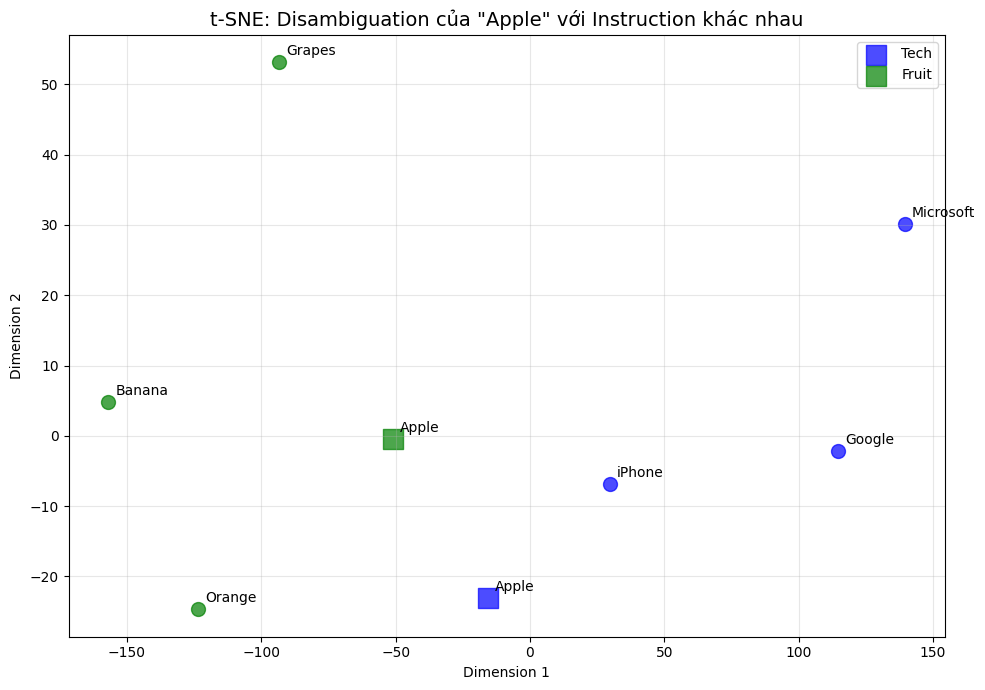


Quan sát, ta thấy: Hai 'Apple' (hình vuông) nằm ở 2 vị trí KHÁC NHAU!
   - Apple (tech) gần với Microsoft, iPhone, Google
   - Apple (fruit) gần với Orange, Banana, Grapes


In [11]:
from sklearn.manifold import TSNE

all_embeddings = np.vstack([embeddings_tech, embeddings_fruit])
all_labels = ["Tech"] * 4 + ["Fruit"] * 4
all_texts = ["Apple", "Microsoft", "iPhone", "Google", "Apple", "Orange", "Banana", "Grapes"]

tsne = TSNE(n_components=2, random_state=42, perplexity=3)
emb_2d = tsne.fit_transform(all_embeddings)

plt.figure(figsize=(10, 7))
colors = {'Tech': 'blue', 'Fruit': 'green'}
for i, (x, y, label, text) in enumerate(zip(emb_2d[:, 0], emb_2d[:, 1], all_labels, all_texts)):
    color = colors[label]
    marker = 's' if text == "Apple" else 'o'
    size = 200 if text == "Apple" else 100
    plt.scatter(x, y, c=color, marker=marker, s=size, alpha=0.7, 
                label=f'{label}' if i in [0, 4] else "")
    plt.annotate(text, (x, y), xytext=(5, 5), textcoords='offset points', fontsize=10)
plt.title('t-SNE: Disambiguation của "Apple" với Instruction khác nhau', fontsize=14)
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nQuan sát, ta thấy: Hai 'Apple' (hình vuông) nằm ở 2 vị trí KHÁC NHAU!")
print("   - Apple (tech) gần với Microsoft, iPhone, Google")
print("   - Apple (fruit) gần với Orange, Banana, Grapes")